In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date, timedelta
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
def calculate_portfolio_volatility(weights, cov_matrix):
    """Calculate portfolio volatility (standard deviation)."""
    cov_times = np.dot(weights, cov_matrix)
    variance = np.dot(weights, cov_times)
    volatility = np.sqrt(variance)
    return volatility

In [3]:
def min_variance_portfolio(mean_returns, cov_matrix):
    """
    Minimum Variance Portfolio (Markowitz).
    
    Minimizes portfolio risk regardless of return.
    Conservative, risk-focused allocation.
    """
    n_assets = len(mean_returns)
    
    def objective(weights):
        return calculate_portfolio_volatility(weights, cov_matrix)
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n_assets))
    x0 = np.array([1/n_assets] * n_assets)
    
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

In [5]:
def max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate):
    """
    Maximum Sharpe Ratio Portfolio.
    
    Optimizes risk-adjusted returns (excess return per unit of risk).
    Best for most investors.
    """
    n_assets = len(mean_returns)
    
    def objective(weights):
        portfolio_return = np.dot(weights, mean_returns)
        cov_times = np.dot(weights, cov_matrix)
        variance = np.dot(weights, cov_times)
        volatility = np.sqrt(variance)
        sharpe_ratio = (portfolio_return - risk_free_rate) / volatility
        return -(sharpe_ratio)  # Minimize negative to maximize
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n_assets))
    x0 = np.array([1/n_assets] * n_assets)
    
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

In [6]:
def risk_parity_portfolio(mean_returns, cov_matrix):
    """
    Risk Parity Portfolio.
    
    Each asset contributes equally to portfolio risk.
    Balances exposure across different volatility levels.
    """
    n_assets = len(mean_returns)
    
    def objective(weights):
        cov_times = np.dot(weights, cov_matrix)
        port_vol = np.sqrt(np.dot(weights, cov_times))
        risk_contribution = weights * cov_times / port_vol
        target_rc = np.sum(risk_contribution) / n_assets
        return np.sum((risk_contribution - target_rc) ** 2)
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n_assets))
    x0 = np.array([1/n_assets] * n_assets)
    
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

In [7]:
def backtest_strategy(weights, prices, returns, rebalance_freq='Q'):
    """
    Backtest a strategy with periodic rebalancing.
    
    Args:
        weights: Initial portfolio weights
        prices: DataFrame of prices (from yfinance)
        returns: DataFrame of daily returns
        rebalance_freq: 'Q' (quarterly), 'M' (monthly), 'A' (annual)
    
    Returns:
        DataFrame with portfolio values over time
    """
    portfolio_values = [1.0]
    dates = [prices.index[0]]
    current_weights = weights.copy()
    
    # trading days
    if rebalance_freq == 'Q':
        rebalance_period = 63  # Quarterly
    elif rebalance_freq == 'M':
        rebalance_period = 21  # Monthly
    else:
        rebalance_period = 252  # Annual
    
    # each day
    for i in range(1, min(len(prices), len(returns))):
        day_returns = returns.iloc[i]
        pct_change = np.sum(current_weights * day_returns)
        new_value = portfolio_values[-1] * (1 + pct_change)
        portfolio_values.append(new_value)
        dates.append(prices.index[i])
        
        # rebalance on schedule
        if i % rebalance_period == 0:
            current_weights = weights.copy()
    
    backtest_df = pd.DataFrame({
        'date': dates,
        'portfolio_value': portfolio_values
    }).set_index('date')
    
    return backtest_df

In [8]:
def calculate_backtest_metrics(backtest_df, risk_free_rate=0.03):
    """Calculate performance metrics from backtest."""
    returns = backtest_df['portfolio_value'].pct_change().dropna()
    
    # CAGR (Compound Annual Growth Rate)
    total_return = backtest_df['portfolio_value'].iloc[-1] / backtest_df['portfolio_value'].iloc[0] - 1
    years = len(backtest_df) / 252
    cagr = (total_return + 1) ** (1/years) - 1
    
    # Volatility
    volatility = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (cagr - risk_free_rate) / volatility
    
    # Maximum Drawdown
    cummax = backtest_df['portfolio_value'].cummax()
    drawdown = (backtest_df['portfolio_value'] - cummax) / cummax
    max_dd = drawdown.min()
    
    return {
        'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Total Return': total_return
    }

In [9]:
class RiskModeler:
    """Analyzes risk metrics for portfolio backtests."""
    
    def __init__(self, backtest_df):
        """
        Initialize risk modeler.
        
        Args:
            backtest_df: DataFrame with portfolio_value column
        """
        self.backtest_df = backtest_df
        self.daily_returns = backtest_df['portfolio_value'].pct_change().dropna()
    
    def historical_var(self, confidence=0.95):
        """Calculate historical Value-at-Risk."""
        return self.daily_returns.quantile(1 - confidence)
    
    def parametric_var(self, confidence=0.95):
        """Calculate parametric (normal distribution) Value-at-Risk."""
        mean = self.daily_returns.mean()
        std = self.daily_returns.std()
        z_score = stats.norm.ppf(1 - confidence)
        return mean + (std * z_score)
    
    def monte_carlo_var(self, confidence=0.95, num_simulations=10000):
        """Calculate Monte Carlo Value-at-Risk."""
        np.random.seed(42)
        mean = self.daily_returns.mean()
        std = self.daily_returns.std()
        simulated_returns = np.random.normal(mean, std, num_simulations)
        return np.percentile(simulated_returns, (1 - confidence) * 100)
    
    def cvar(self, confidence=0.95):
        """Calculate Conditional Value-at-Risk (Expected Shortfall)."""
        var = self.historical_var(confidence)
        return self.daily_returns[self.daily_returns <= var].mean()
    
    def stress_test(self, scenarios=None):
        """
        Stress test portfolio against historical market crashes.
        
        Args:
            scenarios: Dict of {scenario_name: daily_shock}
        
        Returns:
            Dict of {scenario_name: loss_percentage}
        """
        if scenarios is None:
            scenarios = {
                '2008 Worst Day': -0.0916,
                'COVID Crash': -0.1203,
                'Black Monday 1987': -0.2205,
                'Moderate Correction': -0.05,
            }
        
        results = {}
        for name, shock in scenarios.items():
            loss = shock * 100  # Convert to percentage
            results[name] = loss
        
        return results

In [10]:
def plot_optimization_results(backtest_data, metrics_data):
    """
    Create 4-panel portfolio optimization comparison chart.
    
    Args:
        backtest_data: Dict of {strategy_name: backtest_df}
        metrics_data: Dict of {strategy_name: metrics_dict}
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Portfolio Optimizer: Strategy Comparison (5-Year Backtest)', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Cumulative Returns
    ax = axes[0, 0]
    for name, df in backtest_data.items():
        ax.plot(df.index, df['portfolio_value'], label=name, linewidth=2)
    ax.set_title('Cumulative Returns (Starting Value = $1)')
    ax.set_ylabel('Portfolio Value ($)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Drawdown
    ax = axes[0, 1]
    for name, df in backtest_data.items():
        cummax = df['portfolio_value'].cummax()
        drawdown = (df['portfolio_value'] - cummax) / cummax * 100
        ax.plot(drawdown.index, drawdown, label=name, linewidth=2)
    ax.set_title('Drawdown Over Time')
    ax.set_ylabel('Drawdown (%)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Performance Metrics
    ax = axes[1, 0]
    names = list(metrics_data.keys())
    cagr_vals = [metrics_data[n]['CAGR'] * 100 for n in names]
    vol_vals = [metrics_data[n]['Volatility'] * 100 for n in names]
    sharpe_vals = [metrics_data[n]['Sharpe'] for n in names]
    
    x = np.arange(len(names))
    width = 0.25
    ax.bar(x - width, cagr_vals, width, label='CAGR (%)', alpha=0.8)
    ax.bar(x, vol_vals, width, label='Volatility (%)', alpha=0.8)
    ax.bar(x + width, sharpe_vals, width, label='Sharpe Ratio', alpha=0.8)
    ax.set_ylabel('Value')
    ax.set_title('Performance Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Risk vs Return Scatter
    ax = axes[1, 1]
    for name, metrics in metrics_data.items():
        ax.scatter(metrics['Volatility'] * 100, metrics['CAGR'] * 100, 
                  s=200, label=name, alpha=0.7)
        ax.annotate(name, (metrics['Volatility'] * 100, metrics['CAGR'] * 100),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.set_xlabel('Volatility (%)')
    ax.set_ylabel('Return (%)')
    ax.set_title('Risk vs Return')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('portfolio_optimization_results.png', dpi=300, bbox_inches='tight')
    print("✓ Optimization chart saved to 'portfolio_optimization_results.png'")
    plt.show()

In [11]:
def plot_risk_dashboard(backtest_results):
    """
    Create risk modeling dashboard with 3 panels: VaR comparison, risk vs return, stress test.
    
    Args:
        backtest_results: Dict of {strategy_name: backtest_df}
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('VaR & Risk Modeling Dashboard', fontsize=16, fontweight='bold')
    
    # ===== Plot 1: VaR Comparison =====
    ax = axes[0]
    strategy_names = list(backtest_results.keys())
    var_95_vals = []
    cvar_95_vals = []
    
    for name, backtest_df in backtest_results.items():
        daily_ret = backtest_df['portfolio_value'].pct_change().dropna()
        var_95 = daily_ret.quantile(0.05) * 100
        cvar_95 = daily_ret[daily_ret <= daily_ret.quantile(0.05)].mean() * 100
        var_95_vals.append(var_95)
        cvar_95_vals.append(cvar_95)
    
    x = np.arange(len(strategy_names))
    width = 0.35
    ax.bar(x - width/2, var_95_vals, width, label='VaR (95%)', alpha=0.8, color='orange')
    ax.bar(x + width/2, cvar_95_vals, width, label='CVaR (95%)', alpha=0.8, color='red')
    ax.set_ylabel('Daily Loss (%)')
    ax.set_title('Value-at-Risk Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(strategy_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # ===== Plot 2: Risk vs Return =====
    ax = axes[1]
    returns = []
    var_95_risks = []
    strategy_colors = ['blue', 'orange', 'green', 'red']
    
    for name, backtest_df in backtest_results.items():
        total_return = backtest_df['portfolio_value'].iloc[-1] / backtest_df['portfolio_value'].iloc[0] - 1
        years = len(backtest_df) / 252
        cagr = (total_return + 1) ** (1/years) - 1
        
        daily_ret = backtest_df['portfolio_value'].pct_change().dropna()
        var_95 = abs(daily_ret.quantile(0.05)) * 100
        
        returns.append(cagr * 100)
        var_95_risks.append(var_95)
    
    for i, name in enumerate(strategy_names):
        ax.scatter(var_95_risks[i], returns[i], s=300, label=name, alpha=0.7, color=strategy_colors[i])
        ax.annotate(name, (var_95_risks[i], returns[i]), xytext=(5, 5), 
                   textcoords='offset points', fontsize=9)
    ax.set_xlabel('Daily Risk (VaR 95%)')
    ax.set_ylabel('Annual Return (CAGR %)')
    ax.set_title('Risk vs Return Trade-off')
    ax.grid(True, alpha=0.3)
    
    # ===== Plot 3: Stress Test Scenarios =====
    ax = axes[2]
    scenarios = {
        '2008 Worst': -0.0916,
        'COVID': -0.1203,
        'Black Monday': -0.2205,
        'Correction': -0.05,
    }
    
    scenario_names_list = list(scenarios.keys())
    max_sharpe_losses = [loss * 100 for loss in scenarios.values()]
    colors_stress = ['darkred' if loss < -0.10 else 'red' if loss < -0.05 else 'orange' 
                     for loss in scenarios.values()]
    
    ax.barh(scenario_names_list, max_sharpe_losses, color=colors_stress, alpha=0.7)
    ax.set_xlabel('Daily Loss (%)')
    ax.set_title('Stress Test: Max Sharpe Portfolio')
    ax.grid(True, alpha=0.3, axis='x')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    for i, v in enumerate(max_sharpe_losses):
        ax.text(v - 1, i, f'{v:.2f}%', va='center', ha='right', 
               fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.savefig('risk_dashboard.png', dpi=300, bbox_inches='tight')
    print("✓ Risk dashboard saved to 'risk_dashboard.png'")
    plt.show()


PORTFOLIO OPTIMIZATION & RISK MODELING SYSTEM

Loading 5 years of data for 6 assets...
✓ Data loaded: 1253 trading days

RUNNING PORTFOLIO OPTIMIZATIONS

1. Equal Weight (baseline)
   Return: 10.60% | Volatility: 10.72% | Sharpe: 0.709

2. Minimum Variance (Markowitz)
   Return: 1.74% | Volatility: 5.62% | Sharpe: -0.224

3. Maximum Sharpe Ratio
   Return: 17.32% | Volatility: 13.17% | Sharpe: 1.088

4. Risk Parity
   Return: 7.64% | Volatility: 8.28% | Sharpe: 0.561

BACKTESTING STRATEGIES (Historical Performance)

Equal Weight:
   CAGR: 10.33% | Volatility: 10.72% | Sharpe: 0.684 | Max DD: -17.57%

Min Variance:
   CAGR: 1.52% | Volatility: 5.62% | Sharpe: -0.264 | Max DD: -14.22%

Max Sharpe:
   CAGR: 17.58% | Volatility: 13.16% | Sharpe: 1.108 | Max DD: -17.02%

Risk Parity:
   CAGR: 7.40% | Volatility: 8.28% | Sharpe: 0.532 | Max DD: -14.84%

RISK ANALYSIS (Max Sharpe Portfolio)

Value-at-Risk (Daily):
  Historical VaR (95%):   -1.28%
  Parametric VaR (95%):   -1.30%
  Monte Carl

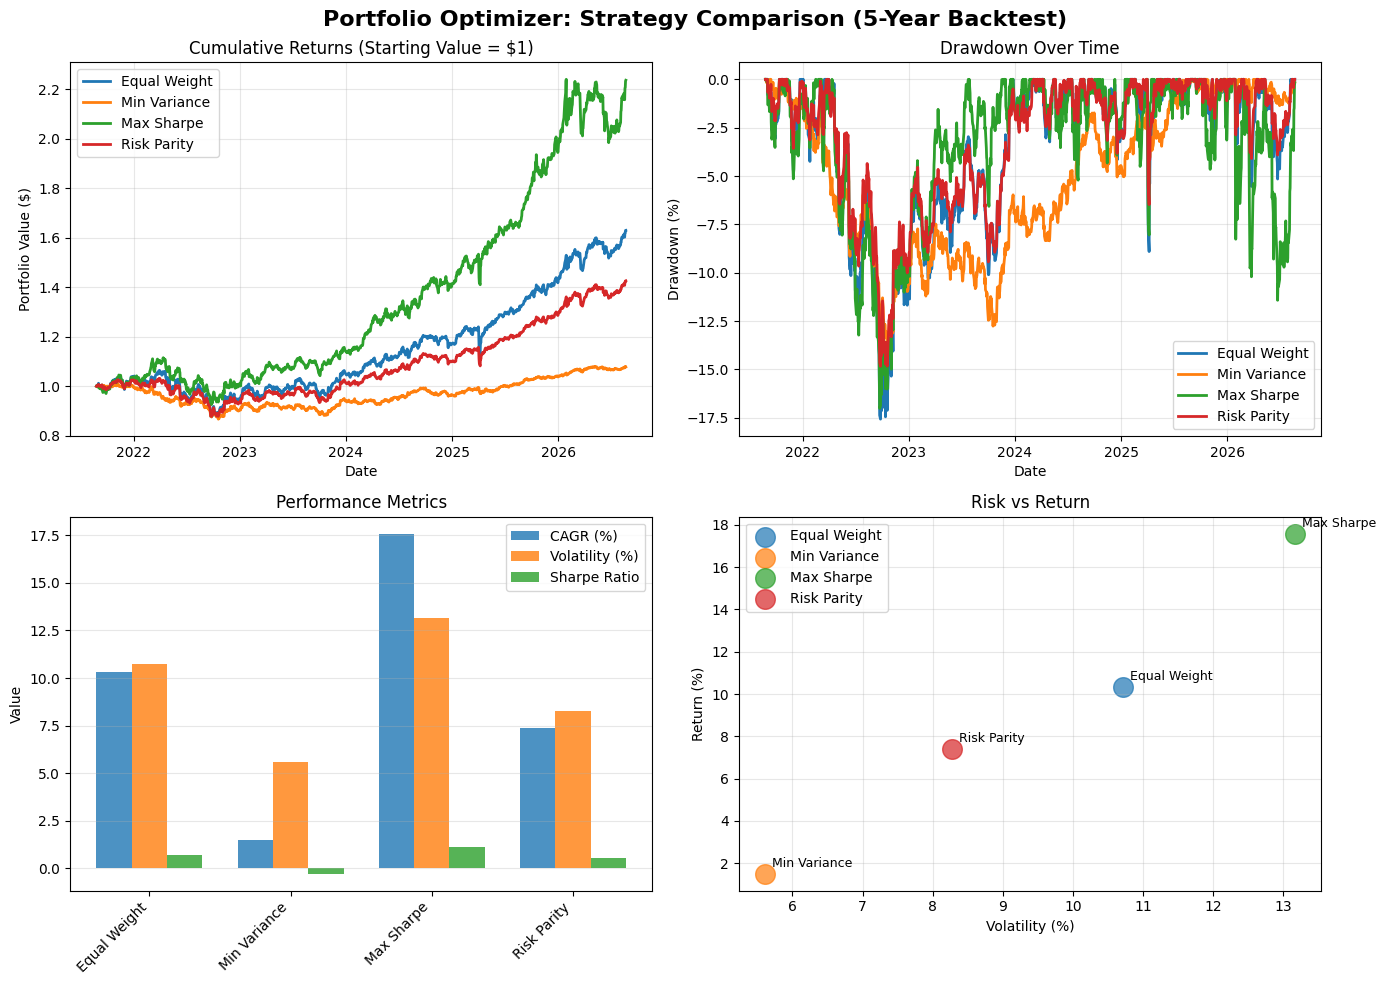

✓ Risk dashboard saved to 'risk_dashboard.png'


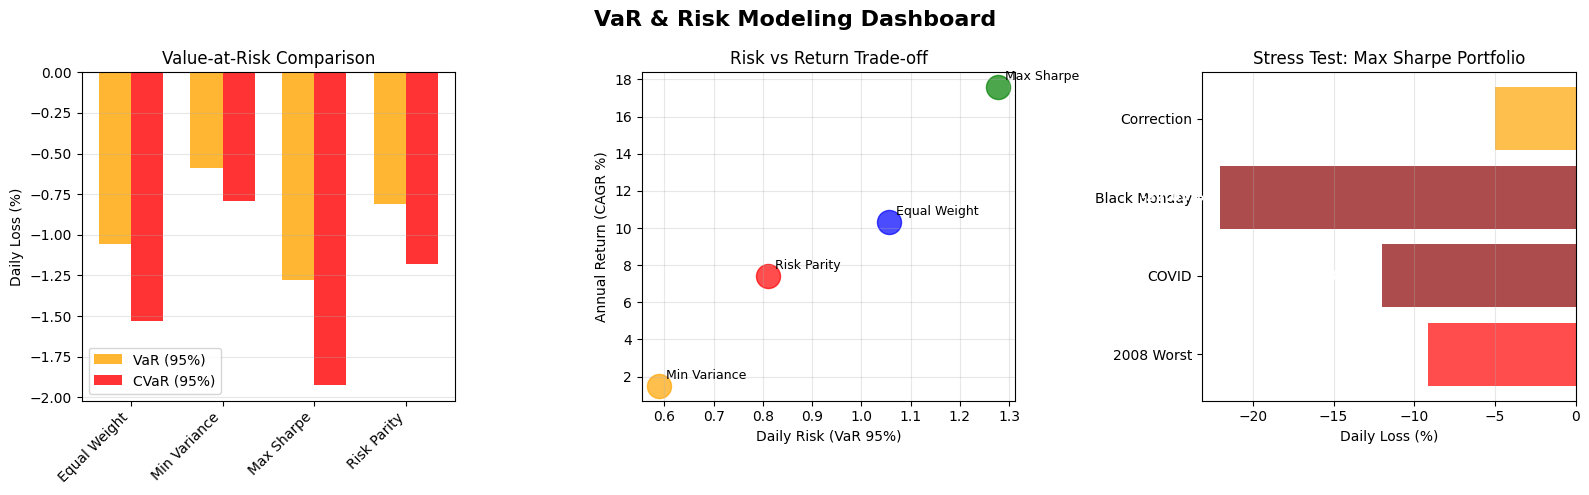


✓ ANALYSIS COMPLETE

Files generated:
  • portfolio_optimization_results.png
  • risk_dashboard.png


In [13]:
if __name__ == "__main__":
    print("\n" + "="*70)
    print("PORTFOLIO OPTIMIZATION & RISK MODELING SYSTEM")
    print("="*70)
    
    # ===== SETUP =====
    tickers = ['SPY', 'EFA', 'BND', 'GLD', 'DBC', 'VNQ']
    end_date = date.today().strftime('%Y-%m-%d')
    start_date = (date.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')
    risk_free_rate = 0.03
    
    # ===== DATA LOADING =====
    print(f"\nLoading 5 years of data for {len(tickers)} assets...")
    prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=False)['Adj Close']
    returns = prices.pct_change().dropna()
    
    mean_returns = returns.mean() * 252
    cov_matrix = returns.cov() * 252
    
    print(f"✓ Data loaded: {len(prices)} trading days")
    
    # ===== OPTIMIZATION =====
    print("\n" + "="*70)
    print("RUNNING PORTFOLIO OPTIMIZATIONS")
    print("="*70)
    
    print("\n1. Equal Weight (baseline)")
    n_assets = len(tickers)
    weights_ew = np.array([1/n_assets] * n_assets)
    ret_ew = np.dot(weights_ew, mean_returns)
    vol_ew = calculate_portfolio_volatility(weights_ew, cov_matrix)
    sharpe_ew = (ret_ew - risk_free_rate) / vol_ew
    print(f"   Return: {ret_ew:.2%} | Volatility: {vol_ew:.2%} | Sharpe: {sharpe_ew:.3f}")
    
    print("\n2. Minimum Variance (Markowitz)")
    weights_mv = min_variance_portfolio(mean_returns, cov_matrix)
    ret_mv = np.dot(weights_mv, mean_returns)
    vol_mv = calculate_portfolio_volatility(weights_mv, cov_matrix)
    sharpe_mv = (ret_mv - risk_free_rate) / vol_mv
    print(f"   Return: {ret_mv:.2%} | Volatility: {vol_mv:.2%} | Sharpe: {sharpe_mv:.3f}")
    
    print("\n3. Maximum Sharpe Ratio")
    weights_ms = max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate)
    ret_ms = np.dot(weights_ms, mean_returns)
    vol_ms = calculate_portfolio_volatility(weights_ms, cov_matrix)
    sharpe_ms = (ret_ms - risk_free_rate) / vol_ms
    print(f"   Return: {ret_ms:.2%} | Volatility: {vol_ms:.2%} | Sharpe: {sharpe_ms:.3f}")
    
    print("\n4. Risk Parity")
    weights_rp = risk_parity_portfolio(mean_returns, cov_matrix)
    ret_rp = np.dot(weights_rp, mean_returns)
    vol_rp = calculate_portfolio_volatility(weights_rp, cov_matrix)
    sharpe_rp = (ret_rp - risk_free_rate) / vol_rp
    print(f"   Return: {ret_rp:.2%} | Volatility: {vol_rp:.2%} | Sharpe: {sharpe_rp:.3f}")
    
    # ===== BACKTESTING =====
    print("\n" + "="*70)
    print("BACKTESTING STRATEGIES (Historical Performance)")
    print("="*70)
    
    backtest_ew = backtest_strategy(weights_ew, prices, returns, rebalance_freq='Q')
    backtest_mv = backtest_strategy(weights_mv, prices, returns, rebalance_freq='Q')
    backtest_ms = backtest_strategy(weights_ms, prices, returns, rebalance_freq='Q')
    backtest_rp = backtest_strategy(weights_rp, prices, returns, rebalance_freq='Q')
    
    metrics_ew = calculate_backtest_metrics(backtest_ew)
    metrics_mv = calculate_backtest_metrics(backtest_mv)
    metrics_ms = calculate_backtest_metrics(backtest_ms)
    metrics_rp = calculate_backtest_metrics(backtest_rp)
    
    print("\nEqual Weight:")
    print(f"   CAGR: {metrics_ew['CAGR']:.2%} | Volatility: {metrics_ew['Volatility']:.2%} | Sharpe: {metrics_ew['Sharpe']:.3f} | Max DD: {metrics_ew['Max Drawdown']:.2%}")
    
    print("\nMin Variance:")
    print(f"   CAGR: {metrics_mv['CAGR']:.2%} | Volatility: {metrics_mv['Volatility']:.2%} | Sharpe: {metrics_mv['Sharpe']:.3f} | Max DD: {metrics_mv['Max Drawdown']:.2%}")
    
    print("\nMax Sharpe:")
    print(f"   CAGR: {metrics_ms['CAGR']:.2%} | Volatility: {metrics_ms['Volatility']:.2%} | Sharpe: {metrics_ms['Sharpe']:.3f} | Max DD: {metrics_ms['Max Drawdown']:.2%}")
    
    print("\nRisk Parity:")
    print(f"   CAGR: {metrics_rp['CAGR']:.2%} | Volatility: {metrics_rp['Volatility']:.2%} | Sharpe: {metrics_rp['Sharpe']:.3f} | Max DD: {metrics_rp['Max Drawdown']:.2%}")
    
    # ===== RISK ANALYSIS =====
    print("\n" + "="*70)
    print("RISK ANALYSIS (Max Sharpe Portfolio)")
    print("="*70)
    
    modeler_ms = RiskModeler(backtest_ms)
    
    print("\nValue-at-Risk (Daily):")
    print(f"  Historical VaR (95%):   {modeler_ms.historical_var(0.95)*100:.2f}%")
    print(f"  Parametric VaR (95%):   {modeler_ms.parametric_var(0.95)*100:.2f}%")
    print(f"  Monte Carlo VaR (95%):  {modeler_ms.monte_carlo_var(0.95)*100:.2f}%")
    
    print(f"\n  Historical VaR (99%):   {modeler_ms.historical_var(0.99)*100:.2f}%")
    print(f"  Parametric VaR (99%):   {modeler_ms.parametric_var(0.99)*100:.2f}%")
    print(f"  Monte Carlo VaR (99%):  {modeler_ms.monte_carlo_var(0.99)*100:.2f}%")
    
    print("\nConditional Value-at-Risk:")
    print(f"  CVaR (95%): {modeler_ms.cvar(0.95)*100:.2f}%")
    print(f"  CVaR (99%): {modeler_ms.cvar(0.99)*100:.2f}%")
    
    print("\nStress Test Scenarios:")
    stress_results = modeler_ms.stress_test()
    for scenario, loss in stress_results.items():
        print(f"  {scenario}: {loss:.2f}%")
    
    # ===== VISUALIZATIONS =====
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    backtest_data = {
        'Equal Weight': backtest_ew,
        'Min Variance': backtest_mv,
        'Max Sharpe': backtest_ms,
        'Risk Parity': backtest_rp
    }
    
    metrics_data = {
        'Equal Weight': metrics_ew,
        'Min Variance': metrics_mv,
        'Max Sharpe': metrics_ms,
        'Risk Parity': metrics_rp
    }
    
    plot_optimization_results(backtest_data, metrics_data)
    plot_risk_dashboard(backtest_data)
    
    print("\n" + "="*70)
    print("✓ ANALYSIS COMPLETE")
    print("="*70)
    print("\nFiles generated:")
    print("  • portfolio_optimization_results.png")
    print("  • risk_dashboard.png")
 